In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
from wordcloud import WordCloud
import networkx as nx
from IPython.display import display, HTML

In [3]:
plt.style.use('fivethirtyeight')
sns.set_palette('viridis')

In [4]:
with open('../data/challenge_set.json', 'r', encoding='utf-8') as f:
    challenge_data = json.load(f)

In [5]:
playlists = challenge_data['playlists']
print(f"Number of playlists: {len(playlists)}")

Number of playlists: 10000


In [6]:
playlist_df = pd.DataFrame([
    {
        'pid': p['pid'],
        'name': p.get('name', 'No Name'),
        'num_tracks': p['num_tracks'],
        'num_samples': p['num_samples'],
        'num_holdouts': p['num_holdouts'],
        'has_name': 'name' in p
    } for p in playlists
])

In [7]:
playlist_df.head()

,pid,name,num_tracks,num_samples,num_holdouts,has_name
0,1000002,spanish playlist,11,0,11,True
1,1000003,Groovin,48,0,48,True
2,1000004,uplift,40,0,40,True
3,1000006,WUBZ,27,0,27,True
4,1000007,new,41,0,41,True


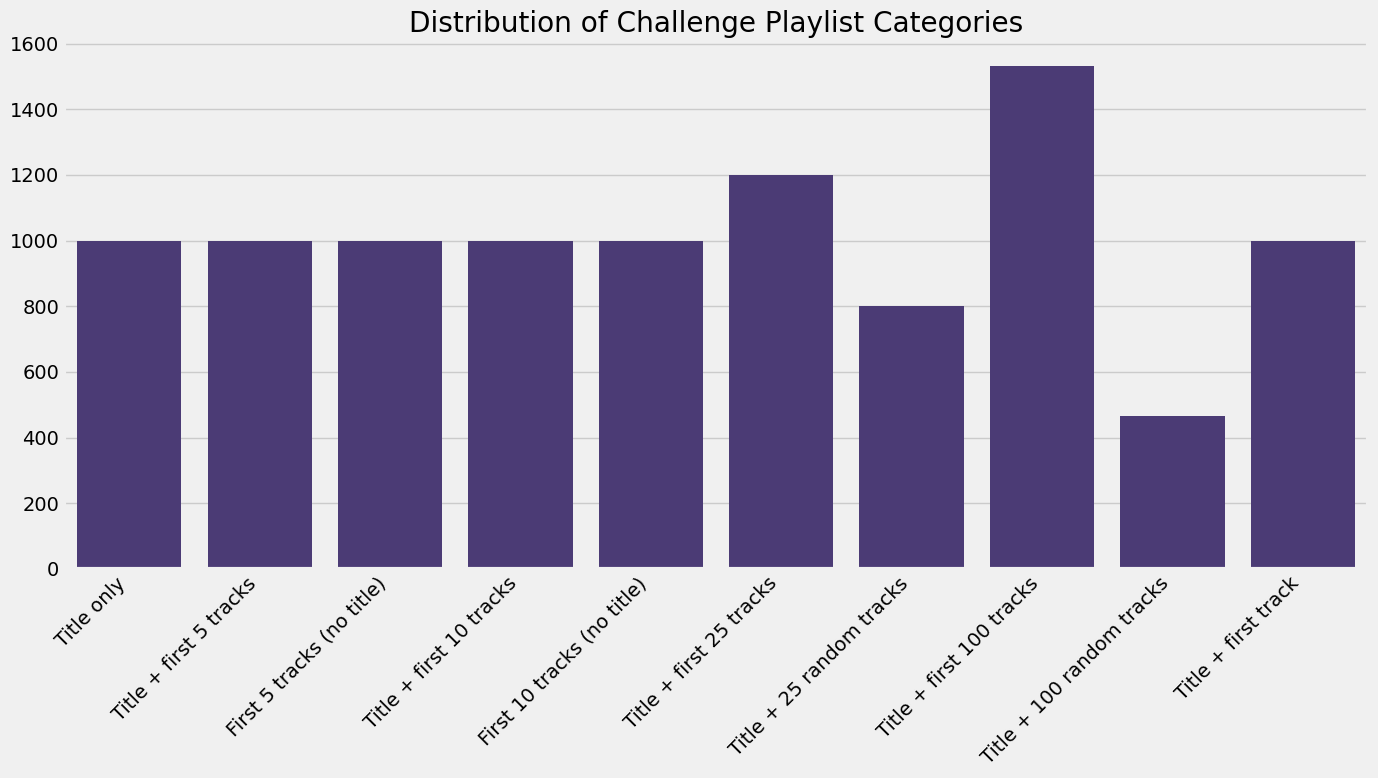

In [8]:
categories = []
for p in playlists:
    has_name = 'name' in p
    num_samples = p['num_samples']
    
    if num_samples == 0 and has_name:
        category = "Title only"
    elif num_samples == 1 and has_name:
        category = "Title + first track"
    elif num_samples == 5 and has_name:
        category = "Title + first 5 tracks"
    elif num_samples == 5 and not has_name:
        category = "First 5 tracks (no title)"
    elif num_samples == 10 and has_name:
        category = "Title + first 10 tracks"
    elif num_samples == 10 and not has_name:
        category = "First 10 tracks (no title)"
    elif num_samples == 25 and has_name and p['tracks'][0]['pos'] == 0:
        category = "Title + first 25 tracks"
    elif num_samples == 25 and has_name:
        category = "Title + 25 random tracks"
    elif num_samples == 100 and has_name and p['tracks'][0]['pos'] == 0:
        category = "Title + first 100 tracks"
    elif num_samples == 100 and has_name:
        category = "Title + 100 random tracks"
    else:
        category = "Other"
        
    categories.append(category)

playlist_df['category'] = categories

# Plot category distribution
plt.figure(figsize=(14, 8))
category_counts = Counter(categories)
sns.barplot(x=list(category_counts.keys()), y=list(category_counts.values()))
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Challenge Playlist Categories')
plt.tight_layout()
plt.show()

Total track occurrences: 281000
Unique tracks: 66243
Unique artists: 14098
Unique albums: 32369


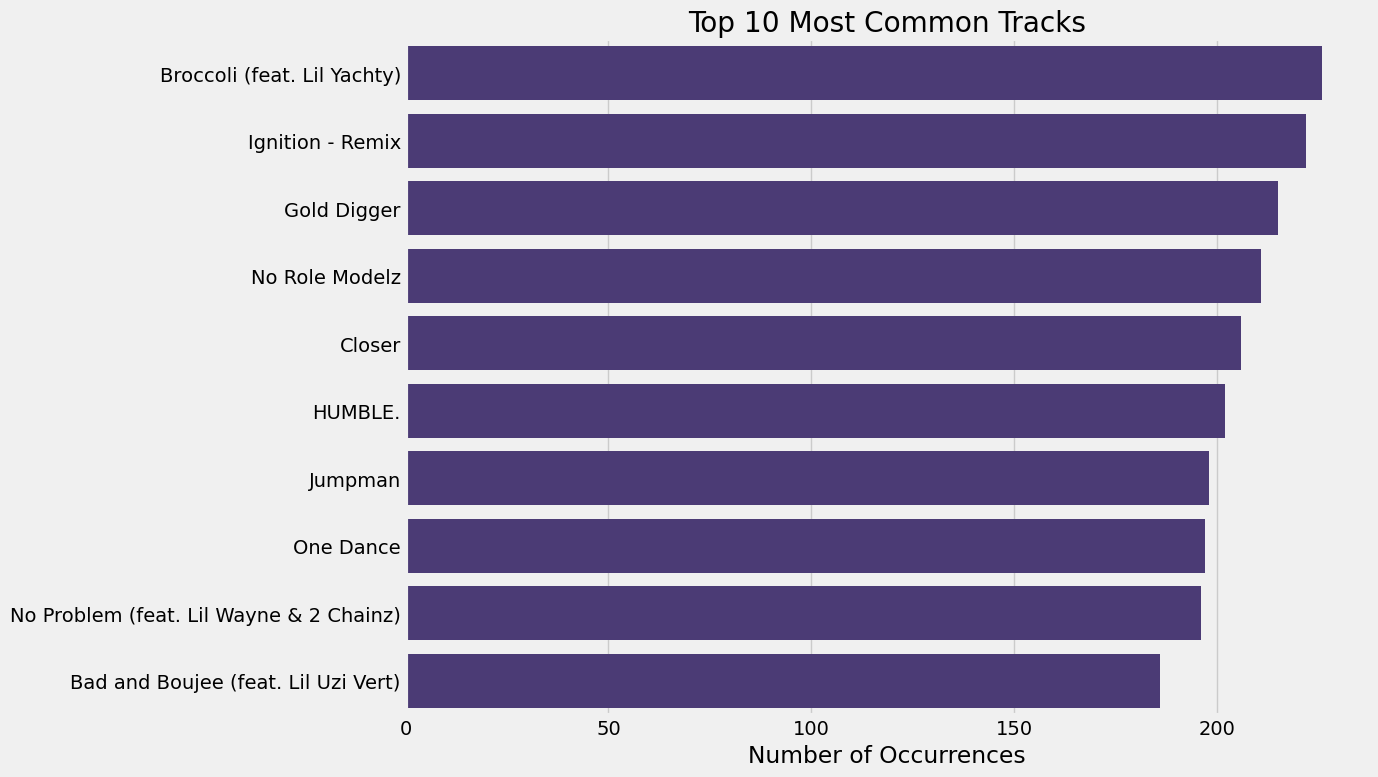

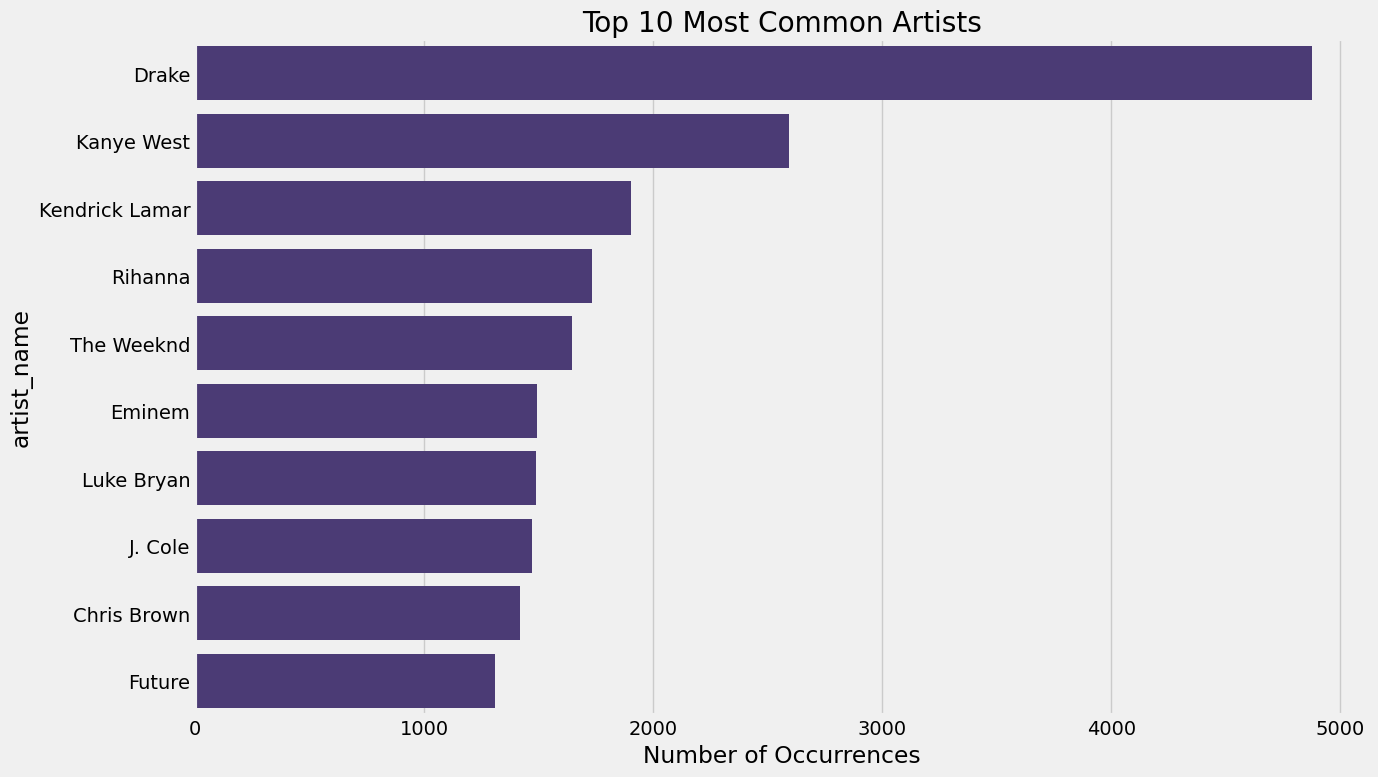

In [9]:
all_tracks = []
for playlist in playlists:
    for track in playlist['tracks']:
        all_tracks.append({
            'track_uri': track['track_uri'],
            'track_name': track['track_name'],
            'artist_name': track['artist_name'],
            'artist_uri': track['artist_uri'],
            'album_name': track['album_name'],
            'album_uri': track['album_uri'],
            'duration_ms': track['duration_ms'],
            'playlist_id': playlist['pid']
        })

# Create tracks dataframe
tracks_df = pd.DataFrame(all_tracks)
print(f"Total track occurrences: {len(tracks_df)}")
print(f"Unique tracks: {tracks_df['track_uri'].nunique()}")
print(f"Unique artists: {tracks_df['artist_uri'].nunique()}")
print(f"Unique albums: {tracks_df['album_uri'].nunique()}")

# Track popularity (frequency)
track_counts = tracks_df['track_uri'].value_counts()
artist_counts = tracks_df['artist_name'].value_counts()

# Plot top tracks
plt.figure(figsize=(14, 8))
top_tracks = track_counts.head(10)
track_names = [tracks_df[tracks_df['track_uri'] == uri]['track_name'].iloc[0] for uri in top_tracks.index]
sns.barplot(x=top_tracks.values, y=track_names)
plt.title('Top 10 Most Common Tracks')
plt.xlabel('Number of Occurrences')
plt.tight_layout()
plt.show()

# Plot top artists
plt.figure(figsize=(14, 8))
top_artists = artist_counts.head(10)
sns.barplot(x=top_artists.values, y=top_artists.index)
plt.title('Top 10 Most Common Artists')
plt.xlabel('Number of Occurrences')
plt.tight_layout()
plt.show()

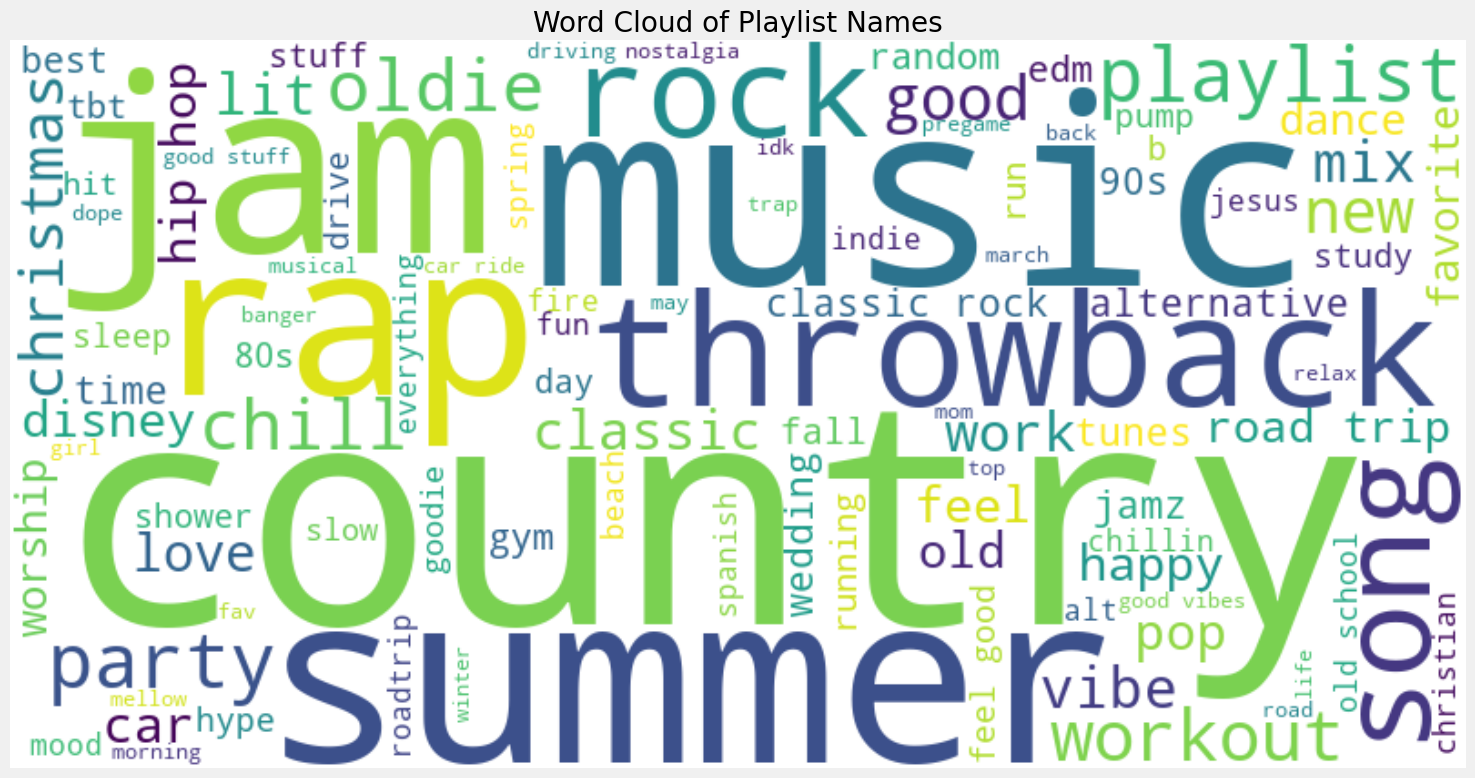

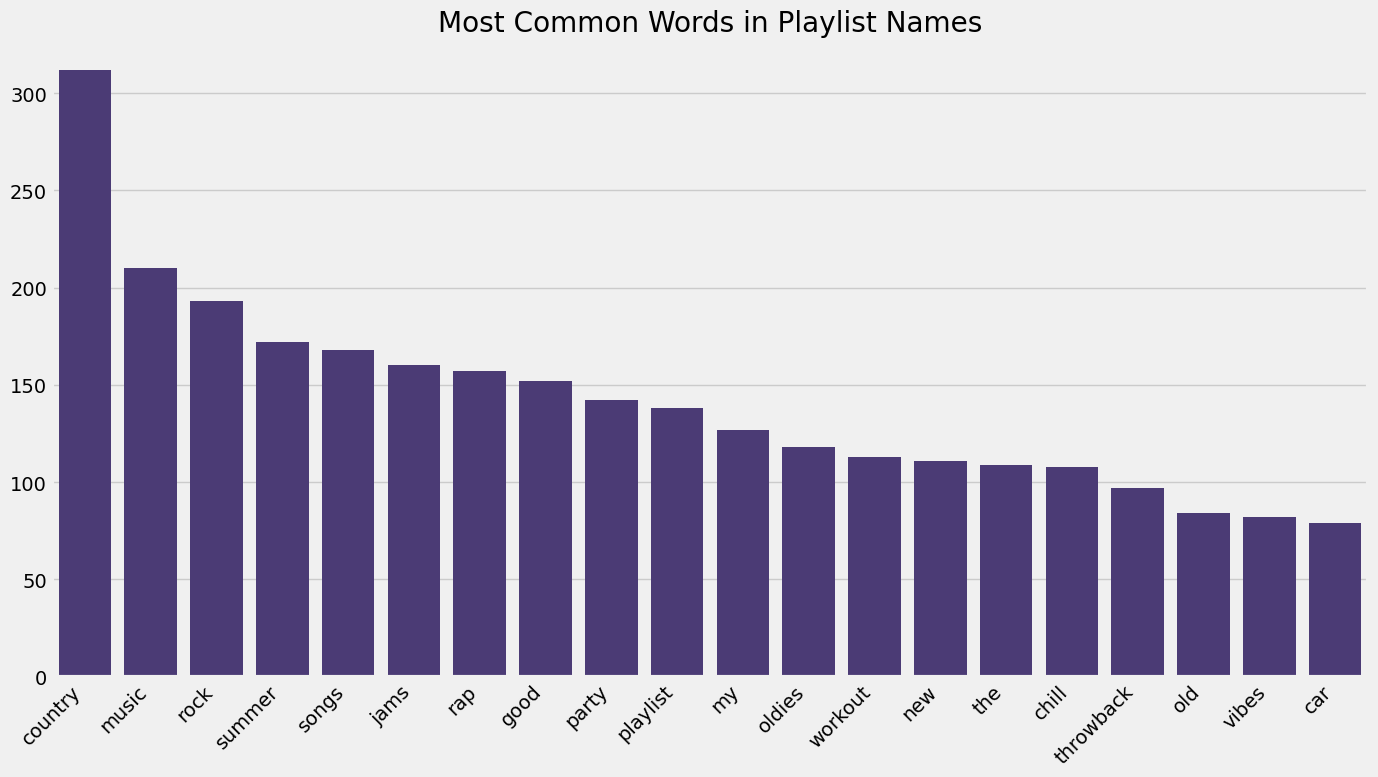

In [10]:
playlist_names = [p.get('name', '') for p in playlists if 'name' in p]
all_names = ' '.join(playlist_names).lower()

# Create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='viridis', max_words=100).generate(all_names)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Playlist Names')
plt.tight_layout()
plt.show()

# Common words in playlist names
words = ' '.join(playlist_names).lower().split()
word_counts = Counter(words)
common_words = word_counts.most_common(20)

plt.figure(figsize=(14, 8))
sns.barplot(x=[word for word, count in common_words], 
            y=[count for word, count in common_words])
plt.title('Most Common Words in Playlist Names')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

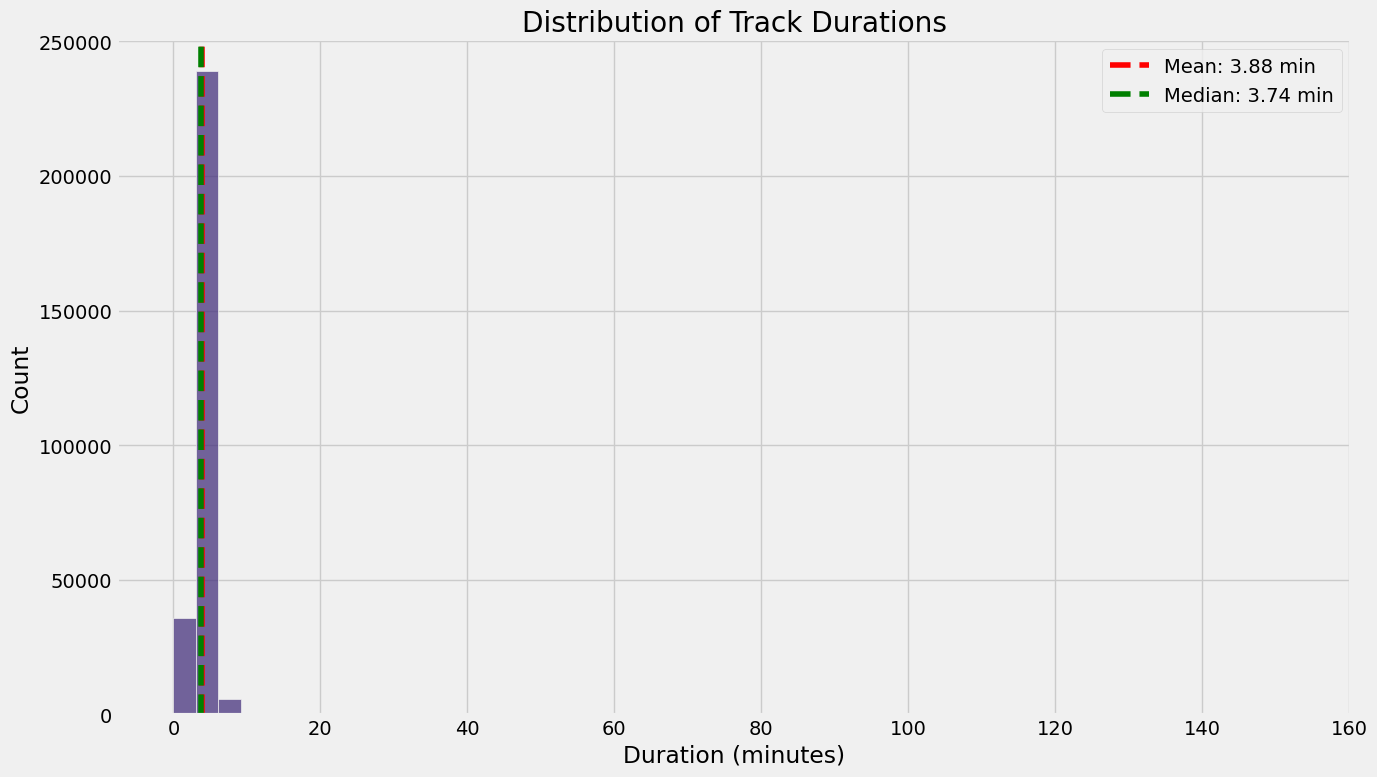

In [11]:
plt.figure(figsize=(14, 8))
tracks_df['duration_min'] = tracks_df['duration_ms'] / 60000  # Convert to minutes
sns.histplot(tracks_df['duration_min'], bins=50)
plt.title('Distribution of Track Durations')
plt.xlabel('Duration (minutes)')
plt.axvline(tracks_df['duration_min'].mean(), color='red', linestyle='--', 
            label=f'Mean: {tracks_df["duration_min"].mean():.2f} min')
plt.axvline(tracks_df['duration_min'].median(), color='green', linestyle='--', 
            label=f'Median: {tracks_df["duration_min"].median():.2f} min')
plt.legend()
plt.tight_layout()
plt.show()

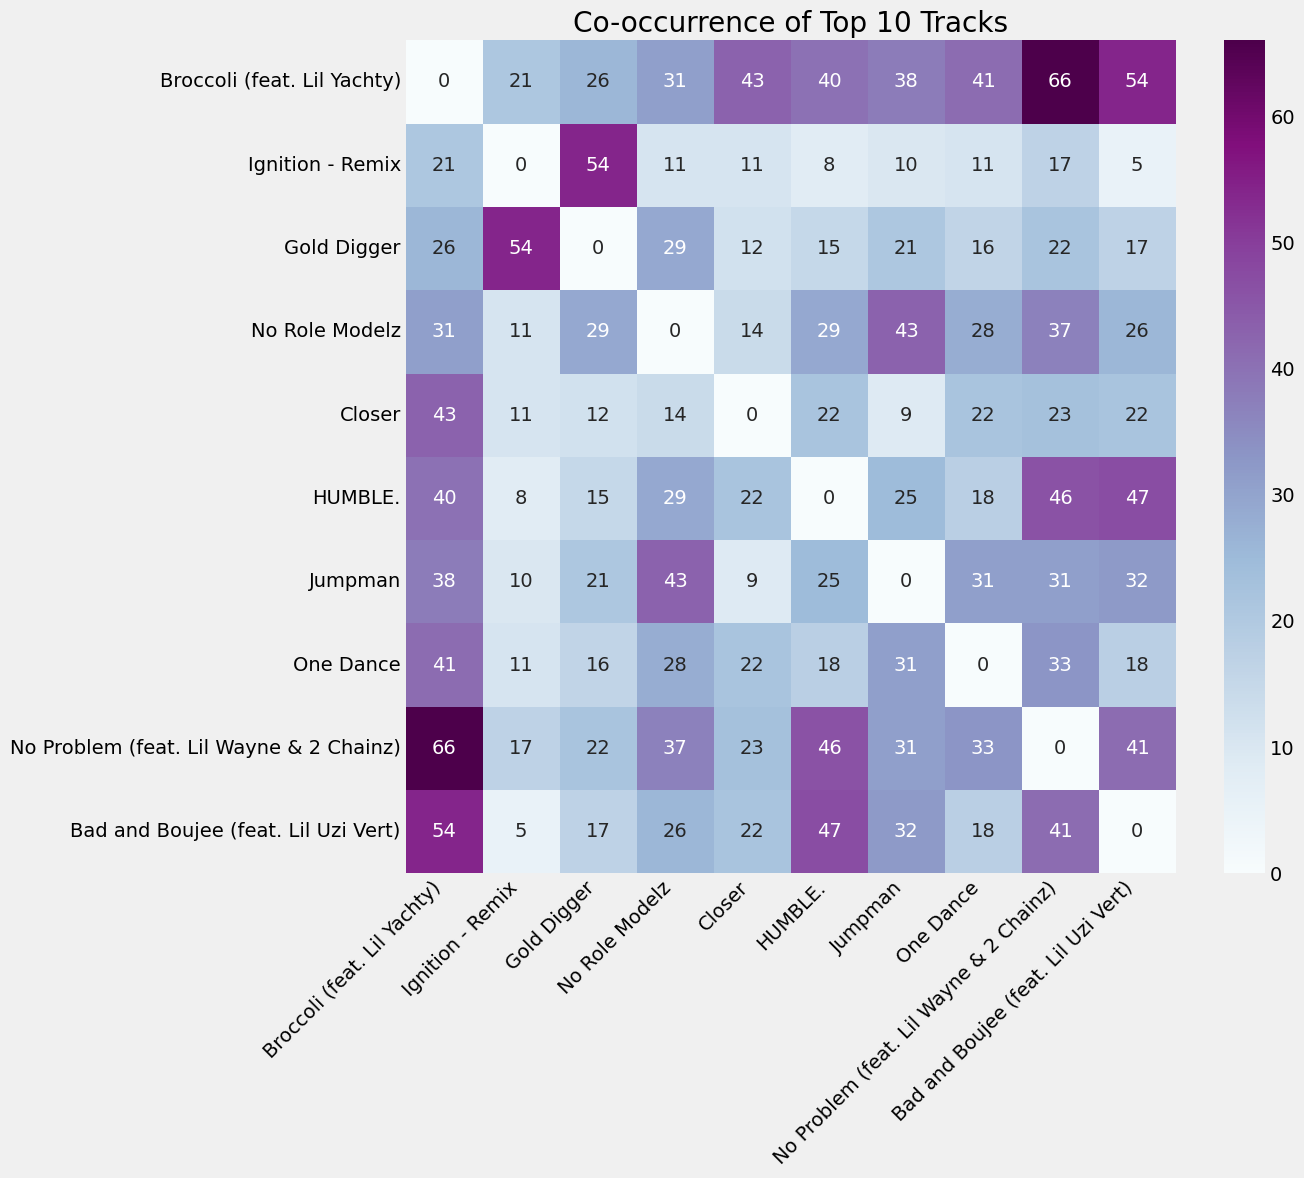

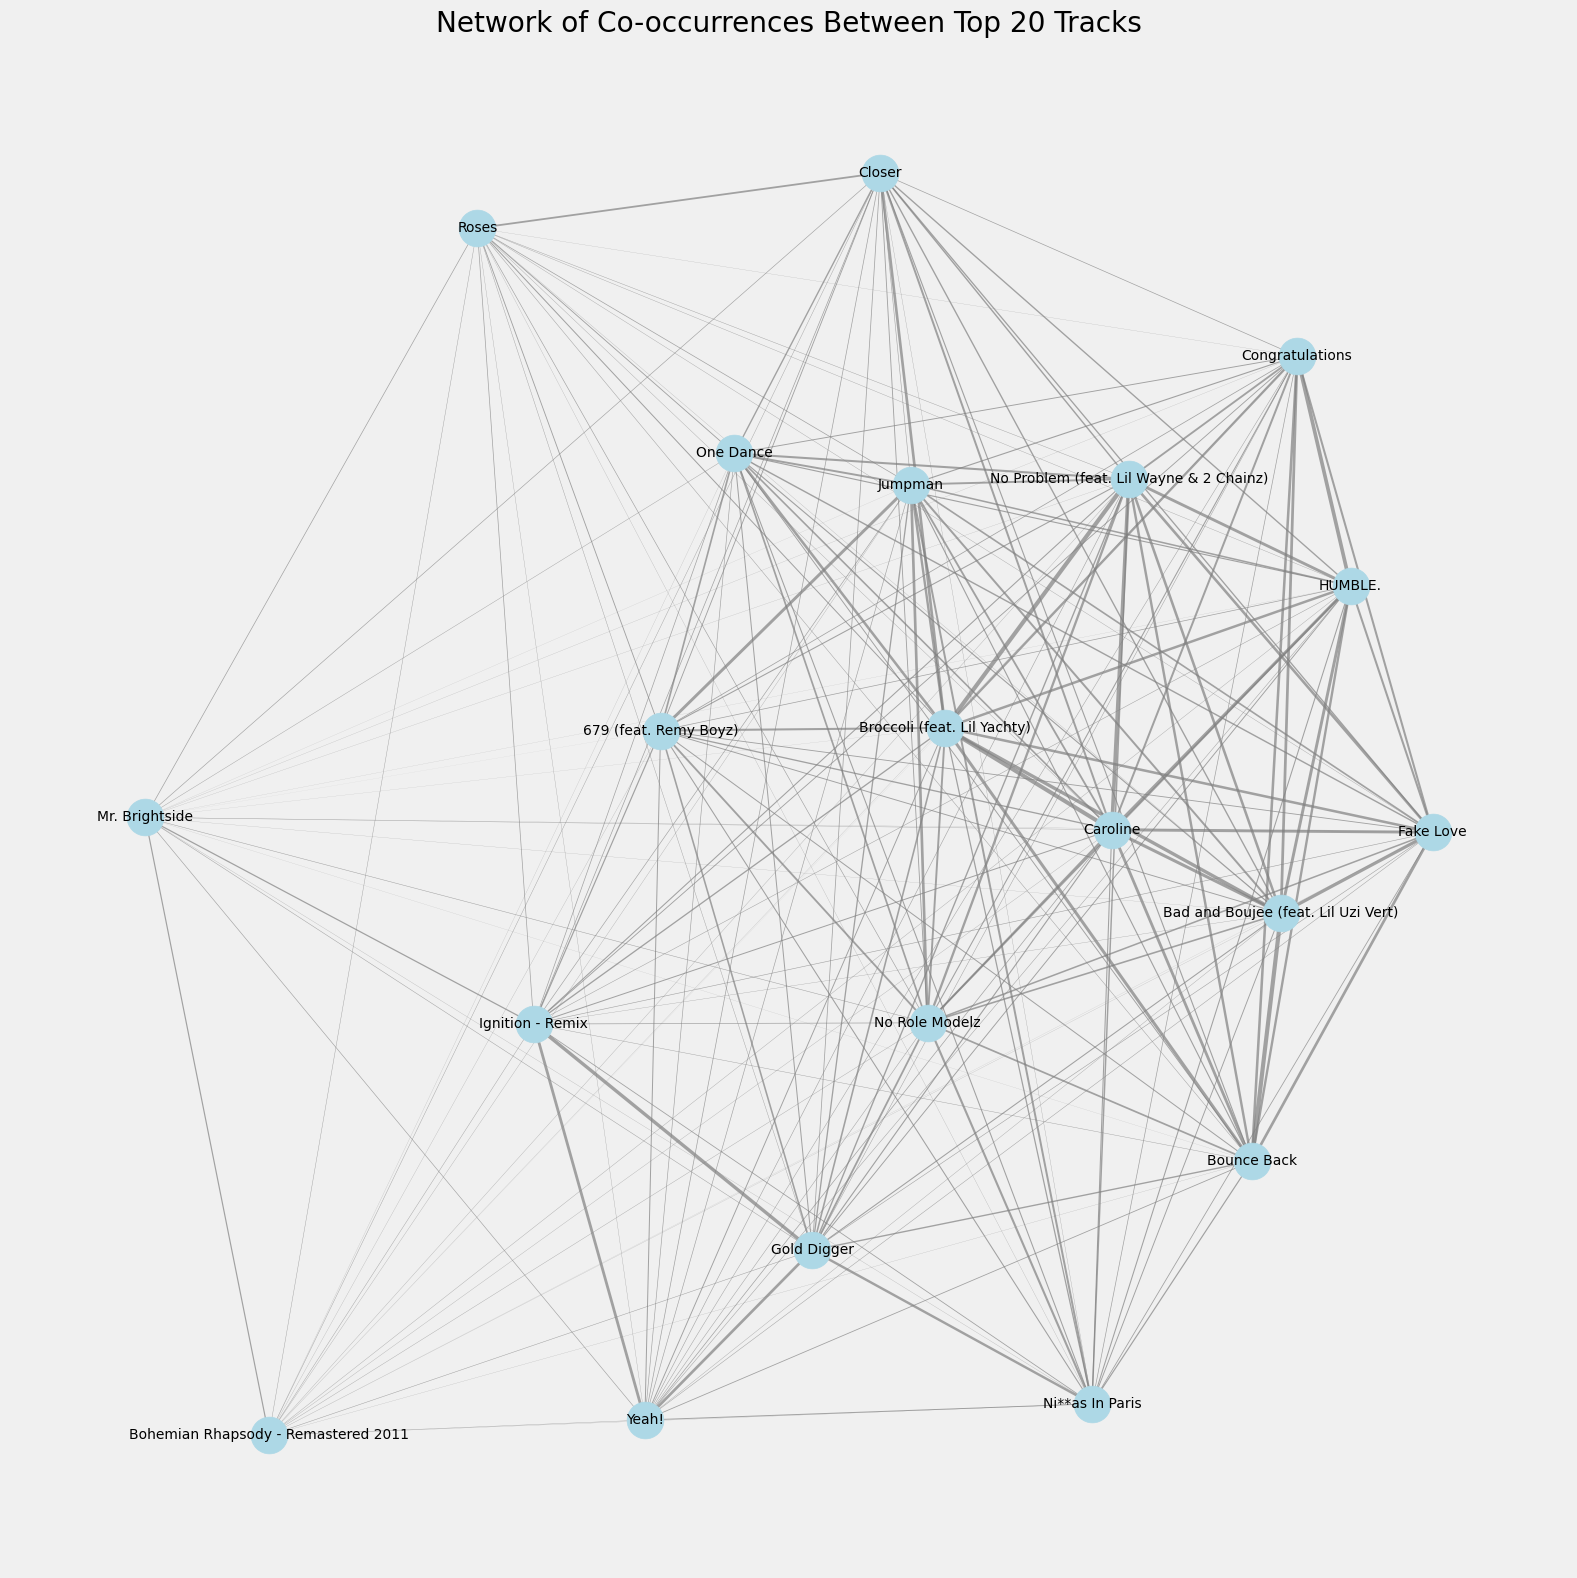

In [16]:
top_track_uris = track_counts.head(10).index.tolist()
track_to_playlists = {}

# Find which playlists contain each track
for track_uri in top_track_uris:
    track_to_playlists[track_uri] = set(
        tracks_df[tracks_df['track_uri'] == track_uri]['playlist_id'].tolist()
    )

# Create co-occurrence matrix
co_occurrence = np.zeros((len(top_track_uris), len(top_track_uris)))

for i, uri1 in enumerate(top_track_uris):
    for j, uri2 in enumerate(top_track_uris):
        if i != j:
            # Count playlists where both tracks appear
            co_occurrence[i, j] = len(
                track_to_playlists[uri1].intersection(track_to_playlists[uri2])
            )

# Get track names for the top tracks
top_track_names = [
    tracks_df[tracks_df['track_uri'] == uri]['track_name'].iloc[0] 
    for uri in top_track_uris
]

# Plot co-occurrence heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    co_occurrence,
    annot=True,
    fmt='g',
    xticklabels=top_track_names,
    yticklabels=top_track_names,
    cmap='BuPu'  # <- pastel colormap
)
plt.title('Co-occurrence of Top 10 Tracks')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Create a network graph of top 20 tracks
plt.figure(figsize=(16, 16))
G = nx.Graph()

# Use top 20 tracks for the graph
top20_track_uris = track_counts.head(20).index.tolist()
top20_track_names = [
    tracks_df[tracks_df['track_uri'] == uri]['track_name'].iloc[0] 
    for uri in top20_track_uris
]

# Add nodes
for name in top20_track_names:
    G.add_node(name)

# Add edges based on co-occurrences
for i, uri1 in enumerate(top20_track_uris):
    for j, uri2 in enumerate(top20_track_uris):
        if i < j:  # Avoid duplicates
            name1 = top20_track_names[i]
            name2 = top20_track_names[j]
            # Find co-occurrences
            playlists1 = set(tracks_df[tracks_df['track_uri'] == uri1]['playlist_id'])
            playlists2 = set(tracks_df[tracks_df['track_uri'] == uri2]['playlist_id'])
            weight = len(playlists1.intersection(playlists2))
            if weight > 0:
                G.add_edge(name1, name2, weight=weight)

# Draw the graph
pos = nx.spring_layout(G, seed=42)
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_weight = max(edge_weights)
normalized_weights = [3 * w / max_weight for w in edge_weights]

nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, width=normalized_weights, alpha=0.7, edge_color='gray')

plt.axis('off')
plt.title('Network of Co-occurrences Between Top 20 Tracks')
plt.tight_layout()
plt.show()